In [1]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Dashboard V2 — Agent Analytics

<table align="left">

  <td>
    <a href="https://colab.research.google.com/github/haiyuan-eng-google/BigQuery-Agent-Analytics-SDK/blob/main/examples/dashboard_v2.ipynb">
      <img src="https://raw.githubusercontent.com/googleapis/python-bigquery-dataframes/refs/heads/main/third_party/logo/colab-logo.png" alt="Colab logo"> Run in Colab
    </a>
  </td>
  <td>
    <a href="https://github.com/haiyuan-eng-google/BigQuery-Agent-Analytics-SDK/blob/main/examples/dashboard_v2.ipynb">
      <img src="https://raw.githubusercontent.com/googleapis/python-bigquery-dataframes/refs/heads/main/third_party/logo/github-logo.png" width="32" alt="GitHub logo">
      View on GitHub
    </a>
  </td>
  <td>
    <a href="https://console.cloud.google.com/vertex-ai/workbench/deploy-notebook?download_url=https://raw.githubusercontent.com/haiyuan-eng-google/BigQuery-Agent-Analytics-SDK/main/examples/dashboard_v2.ipynb">
      <img src="https://www.gstatic.com/images/branding/product/1x/google_cloud_48dp.png" alt="Vertex AI logo" width="32">
      Open in Vertex AI Workbench
    </a>
  </td>
  <td>
    <a href="https://console.cloud.google.com/bigquery/import?url=https://github.com/haiyuan-eng-google/BigQuery-Agent-Analytics-SDK/blob/main/examples/dashboard_v2.ipynb">
      <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTW1gvOovVlbZAIZylUtf5Iu8-693qS1w5NJw&s" alt="BQ logo" width="35">
      Open in BQ Studio
    </a>
  </td>
</table>

A self-contained notebook that queries BigQuery directly with raw SQL.
No SDK imports — all logic lives in SQL + pandas/matplotlib.

**Architecture**: 2-layer SQL
- **Layer 1** (cells 2-8): Canonical base temp tables that extract typed columns once.
  Rules copied from the ADK plugin schema, `views.py`, `event_semantics.py`, and `evaluators.py`.
- **Layer 2** (cells 9+): Chart queries that only read from Layer 1 temp tables.
  No `JSON_VALUE`/`JSON_QUERY` in chart cells.

**Source-of-truth hierarchy**:
1. ADK plugin schema (`bigquery_agent_analytics_plugin.py`) — columns, types, JSON structure
2. SDK semantic mirrors (`views.py`, `event_semantics.py`) — per-event extraction, event families
3. SDK aggregation patterns (`evaluators.py`) — session rollups, token COALESCE

## Cell 0: Setup

In [2]:
import subprocess, sys

# Install dependencies (non-fatal for managed environments)
subprocess.call(
    [sys.executable, "-m", "pip", "install", "-q",
     "--break-system-packages",
     "google-cloud-bigquery", "pandas", "matplotlib", "db-dtypes"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)

import os
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="google")

print("Dependencies loaded.")

Dependencies loaded.


## Cell 1: Configuration + Filter Block

In [3]:
# ---------- Configuration (user-provided) ----------
PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "<Your BQAA Project Id>")
DATASET_ID = os.environ.get("BQ_DATASET", "<Your Dataset Id>")
TABLE_ID   = os.environ.get("BQ_TABLE", "<Your Table Id>")
TABLE_REF  = f"`{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`"
LOCATION   = os.environ.get("<Your Dataset Location>") or None  # e.g., "us-central1", None = auto

# ---------- Required filters (top-level, every query) ----------
TIME_RANGE_HOURS   = 720         # default: last 30 days
AGENT_FILTER       = None        # e.g., "my-agent" or None for all
USER_ID_FILTER     = None
SESSION_ID_FILTER  = None
TRACE_ID_FILTER    = None

# ---------- Advanced filters (drill-down, opt-in) ----------
EVENT_TYPE_FILTER      = None    # list of event types, e.g. ["LLM_REQUEST","LLM_RESPONSE"]
INVOCATION_ID_FILTER   = None
SPAN_ID_FILTER         = None
TOOL_ORIGIN_FILTER     = None
LABEL_FILTERS          = None    # dict, e.g. {"env": "prod"}
SESSION_META_FILTERS   = None    # dict, e.g. {"customer_id": "abc"}

# ---------- BigQuery client with session ----------
client = bigquery.Client(project=PROJECT_ID, location=LOCATION)

# Create a session so CREATE TEMP TABLE works across cells
_session_job = client.query(
    "SELECT 1",
    job_config=bigquery.QueryJobConfig(create_session=True),
)
_session_job.result()
SESSION_ID = _session_job.session_info.session_id
print(f"Session  : {SESSION_ID}")

def _job_config():
    cfg = bigquery.QueryJobConfig()
    cfg.connection_properties = [
        bigquery.query.ConnectionProperty("session_id", SESSION_ID)
    ]
    return cfg

def run(sql):
    """Execute SQL within the BQ session and return a DataFrame."""
    return client.query(sql, job_config=_job_config()).to_dataframe()

def execute(sql):
    """Execute SQL within the BQ session (no result needed)."""
    client.query(sql, job_config=_job_config()).result()

def where_clause():
    """Build WHERE clause from all active filters."""
    conds = [
        f"timestamp >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL {TIME_RANGE_HOURS} HOUR)"
    ]
    if AGENT_FILTER:
        conds.append(f"agent = '{AGENT_FILTER}'")
    if USER_ID_FILTER:
        conds.append(f"user_id = '{USER_ID_FILTER}'")
    if SESSION_ID_FILTER:
        conds.append(f"session_id = '{SESSION_ID_FILTER}'")
    if TRACE_ID_FILTER:
        conds.append(f"trace_id = '{TRACE_ID_FILTER}'")
    if EVENT_TYPE_FILTER:
        types = ",".join(f"'{t}'" for t in EVENT_TYPE_FILTER)
        conds.append(f"event_type IN ({types})")
    if INVOCATION_ID_FILTER:
        conds.append(f"invocation_id = '{INVOCATION_ID_FILTER}'")
    if SPAN_ID_FILTER:
        conds.append(f"span_id = '{SPAN_ID_FILTER}'")
    if TOOL_ORIGIN_FILTER:
        conds.append(f"JSON_VALUE(content, '$.tool_origin') = '{TOOL_ORIGIN_FILTER}'")
    if LABEL_FILTERS:
        for k, v in LABEL_FILTERS.items():
            conds.append(f"JSON_VALUE(attributes, '$.labels.{k}') = '{v}'")
    if SESSION_META_FILTERS:
        for k, v in SESSION_META_FILTERS.items():
            conds.append(f"JSON_VALUE(attributes, '$.session_metadata.state.{k}') = '{v}'")
    return " AND ".join(conds)

print(f"Project  : {PROJECT_ID}")
print(f"Location : {LOCATION or '(auto)'}")
print(f"Dataset  : {DATASET_ID}")
print(f"Table    : {TABLE_ID}")
print(f"Time     : last {TIME_RANGE_HOURS} hours")
print(f"WHERE    : {where_clause()[:120]}...")

Session  : ChoKGHRlc3QtcHJvamVjdC0wNzI4LTQ2NzMyMxABGiRmNjNhOTk0Yy0yZGYxLTRjY2QtODk4Zi1lYjJiMzY0YTc2NDA=
Project  : <Your BQAA Project Id>
Location : <Your Dataset Location>
Dataset  : <Your Dataset Id>
Table    : <Your Table Id>
Time     : last 720 hours
WHERE    : timestamp >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 720 HOUR)...


---
# Layer 1: Base Tables

Canonical extraction CTEs. Each cell creates a `CREATE TEMP TABLE` with typed columns.
Chart cells (Layer 2) only reference these temp tables.

### Cell 2: `filtered_events` — master filtered event stream

In [4]:
# Cell 2: filtered_events
# Sources: plugin schema (columns), event_semantics.py:136-159 (families), event_semantics.py:128 (error)
where = where_clause()
sql = f"""
CREATE TEMP TABLE filtered_events AS
SELECT
  -- identity / grouping (plugin schema)
  timestamp,
  event_type,
  agent,
  session_id,
  invocation_id,
  user_id,
  trace_id,
  span_id,
  parent_span_id,
  -- event routing
  status,
  error_message,
  is_truncated,
  -- event family (event_semantics.py:136-159)
  CASE
    WHEN event_type = 'USER_MESSAGE_RECEIVED' THEN 'user'
    WHEN event_type IN ('INVOCATION_STARTING','INVOCATION_COMPLETED') THEN 'invocation'
    WHEN event_type IN ('AGENT_STARTING','AGENT_COMPLETED') THEN 'agent'
    WHEN event_type IN ('LLM_REQUEST','LLM_RESPONSE','LLM_ERROR') THEN 'llm'
    WHEN event_type IN ('TOOL_STARTING','TOOL_COMPLETED','TOOL_ERROR') THEN 'tool'
    WHEN event_type = 'STATE_DELTA' THEN 'state'
    WHEN event_type LIKE 'HITL_%' THEN 'hitl'
    ELSE 'other'
  END AS event_family,
  -- canonical error flag (event_semantics.py:128)
  (ENDS_WITH(event_type, '_ERROR')
   OR error_message IS NOT NULL
   OR status = 'ERROR') AS is_error,
  -- cross-cutting filter dimensions (plugin schema: attributes JSON keys)
  JSON_QUERY(attributes, '$.labels') AS labels,
  JSON_QUERY(attributes, '$.session_metadata') AS session_metadata,
  -- raw JSON (used by downstream base cells only, never by chart cells)
  content,
  attributes,
  latency_ms,
  content_parts
FROM {TABLE_REF}
WHERE {where}
"""
execute(sql)
count = run("SELECT COUNT(*) AS n, COUNT(DISTINCT session_id) AS sessions FROM filtered_events")
print(f"filtered_events: {count['n'][0]:,} events across {count['sessions'][0]:,} sessions")

filtered_events: 148 events across 6 sessions


### Cell 3: `llm_events` — typed LLM extraction

In [5]:
# Cell 3: llm_events
# Sources: views.py:78-98 (per-event), evaluators.py:682-712 (token COALESCE)
sql = """
CREATE TEMP TABLE llm_events AS
SELECT
  timestamp, agent, session_id, invocation_id, user_id,
  trace_id, span_id, parent_span_id,
  event_type, status, error_message,
  (ENDS_WITH(event_type, '_ERROR') OR error_message IS NOT NULL OR status = 'ERROR') AS is_error,
  -- LLM_REQUEST fields (views.py:80-84)
  JSON_VALUE(attributes, '$.model') AS model,
  JSON_QUERY(attributes, '$.llm_config') AS llm_config,
  -- LLM_RESPONSE fields (views.py:89-98)
  CAST(JSON_VALUE(content, '$.usage.prompt') AS INT64) AS usage_prompt_tokens,
  CAST(JSON_VALUE(content, '$.usage.completion') AS INT64) AS usage_completion_tokens,
  CAST(JSON_VALUE(content, '$.usage.total') AS INT64) AS usage_total_tokens,
  JSON_VALUE(attributes, '$.model_version') AS model_version,
  -- latency (views.py:93-96)
  CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms,
  CAST(JSON_VALUE(latency_ms, '$.time_to_first_token_ms') AS FLOAT64) AS ttft_ms,
  -- token extraction: 3-way COALESCE (evaluators.py:682-712)
  COALESCE(
    CAST(JSON_VALUE(attributes, '$.usage_metadata.prompt_token_count') AS INT64),
    CAST(JSON_VALUE(content, '$.usage.prompt') AS INT64),
    CAST(JSON_VALUE(attributes, '$.input_tokens') AS INT64)
  ) AS prompt_tokens,
  COALESCE(
    CAST(JSON_VALUE(attributes, '$.usage_metadata.candidates_token_count') AS INT64),
    CAST(JSON_VALUE(content, '$.usage.completion') AS INT64),
    CAST(JSON_VALUE(attributes, '$.output_tokens') AS INT64)
  ) AS completion_tokens,
  COALESCE(
    CAST(JSON_VALUE(attributes, '$.usage_metadata.total_token_count') AS INT64),
    CAST(JSON_VALUE(content, '$.usage.total') AS INT64),
    COALESCE(
      CAST(JSON_VALUE(attributes, '$.input_tokens') AS INT64), 0
    ) + COALESCE(
      CAST(JSON_VALUE(attributes, '$.output_tokens') AS INT64), 0
    )
  ) AS total_tokens
FROM filtered_events
WHERE event_family = 'llm'
"""
execute(sql)
count = run("SELECT COUNT(*) AS n, COUNTIF(event_type='LLM_RESPONSE') AS responses FROM llm_events")
print(f"llm_events: {count['n'][0]:,} events ({count['responses'][0]:,} responses)")

llm_events: 48 events (24 responses)


### Cell 4: `tool_events` — typed tool extraction

In [6]:
# Cell 4: tool_events
# Sources: views.py:105-126 (per-event typed extraction)
sql = """
CREATE TEMP TABLE tool_events AS
SELECT
  timestamp, agent, session_id, invocation_id, user_id,
  trace_id, span_id, parent_span_id,
  event_type, status, error_message,
  (ENDS_WITH(event_type, '_ERROR') OR error_message IS NOT NULL OR status = 'ERROR') AS is_error,
  JSON_VALUE(content, '$.tool') AS tool_name,
  JSON_VALUE(content, '$.tool_origin') AS tool_origin,
  JSON_QUERY(content, '$.args') AS tool_args,
  JSON_QUERY(content, '$.result') AS tool_result,
  CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms
FROM filtered_events
WHERE event_family = 'tool'
"""
execute(sql)
count = run("SELECT COUNT(*) AS n, COUNT(DISTINCT tool_name) AS tools FROM tool_events")
print(f"tool_events: {count['n'][0]:,} events across {count['tools'][0]:,} distinct tools")

tool_events: 50 events across 4 distinct tools


### Cell 5: `session_rollups` — per-session aggregation

In [7]:
# Cell 5: session_rollups
# Sources: evaluators.py SESSION_SUMMARY_QUERY pattern
sql = """
CREATE TEMP TABLE session_rollups AS
SELECT
  session_id,
  ANY_VALUE(agent) AS agent,
  ANY_VALUE(user_id) AS user_id,
  MIN(trace_id) AS first_trace_id,
  MIN(timestamp) AS start_ts,
  MAX(timestamp) AS end_ts,
  TIMESTAMP_DIFF(MAX(timestamp), MIN(timestamp), MILLISECOND) AS duration_ms,
  COUNT(*) AS total_events,
  COUNTIF(event_type = 'LLM_REQUEST') AS llm_calls,
  COUNTIF(event_type = 'TOOL_STARTING') AS tool_calls,
  COUNTIF(event_type = 'TOOL_ERROR') AS tool_errors,
  COUNTIF(event_type = 'LLM_ERROR') AS llm_errors,
  COUNTIF(event_type LIKE 'HITL_%') AS hitl_events,
  COUNTIF(event_type = 'USER_MESSAGE_RECEIVED') AS turn_count,
  COUNTIF(event_type = 'STATE_DELTA') AS state_deltas,
  COUNTIF(is_error) > 0 AS has_error,
  COUNTIF(content_parts IS NOT NULL AND ARRAY_LENGTH(content_parts) > 0) > 0 AS has_multimodal,
  COUNT(DISTINCT invocation_id) AS invocation_count,
  COUNT(DISTINCT trace_id) AS trace_count,
  ANY_VALUE(labels) AS labels,
  ANY_VALUE(session_metadata) AS session_metadata
FROM filtered_events
GROUP BY session_id
"""
execute(sql)
count = run("SELECT COUNT(*) AS n FROM session_rollups")
print(f"session_rollups: {count['n'][0]:,} sessions")

session_rollups: 6 sessions


### Cell 6: `hitl_events` — typed HITL extraction

In [8]:
# Cell 6: hitl_events
# Sources: plugin schema + views.py:151-186 (raw fields),
#          event_semantics.py:126,131,151-157 (hitl_type, is_completed)
sql = """
CREATE TEMP TABLE hitl_events AS
SELECT
  timestamp, agent, session_id, invocation_id, user_id,
  trace_id, span_id, event_type,
  -- event_semantics.py classification
  CASE
    WHEN event_type LIKE 'HITL_CREDENTIAL%' THEN 'credential'
    WHEN event_type LIKE 'HITL_CONFIRMATION%' THEN 'confirmation'
    WHEN event_type LIKE 'HITL_INPUT%' THEN 'input'
  END AS hitl_type,
  event_type LIKE '%_COMPLETED' AS is_completed,
  -- views.py per-event typed extraction
  JSON_VALUE(content, '$.tool') AS tool_name,
  JSON_QUERY(content, '$.args') AS tool_args,
  JSON_QUERY(content, '$.result') AS tool_result
FROM filtered_events
WHERE event_family = 'hitl'
"""
execute(sql)
count = run("SELECT COUNT(*) AS n FROM hitl_events")
print(f"hitl_events: {count['n'][0]:,} events")

hitl_events: 0 events


### Cell 7: `multimodal_parts` — content_parts unnest

In [9]:
# Cell 7: multimodal_parts
# Sources: plugin schema (content_parts RECORD at :1594)
sql = """
CREATE TEMP TABLE multimodal_parts AS
SELECT
  fe.timestamp,
  fe.agent,
  fe.session_id,
  fe.event_type,
  fe.event_family,
  fe.is_truncated,
  cp.mime_type,
  REGEXP_EXTRACT(cp.mime_type, r'^([^/]+)') AS mime_family,
  cp.storage_mode,
  cp.uri,
  cp.text IS NOT NULL AS has_inline_text,
  cp.part_index
FROM filtered_events fe, UNNEST(fe.content_parts) AS cp
WHERE fe.content_parts IS NOT NULL
"""
execute(sql)
count = run("SELECT COUNT(*) AS n, COUNT(DISTINCT mime_family) AS families FROM multimodal_parts")
print(f"multimodal_parts: {count['n'][0]:,} parts across {count['families'][0]:,} mime families")

multimodal_parts: 162 parts across 2 mime families


### Cell 8: `trace_rollups` — per-trace aggregation

In [10]:
# Cell 8: trace_rollups
# Sources: plugin schema (trace_id, span_id, parent_span_id)
#          labels/session_metadata: pass-through from filtered_events
sql = """
CREATE TEMP TABLE trace_rollups AS
SELECT
  trace_id,
  ANY_VALUE(session_id) AS session_id,
  ANY_VALUE(agent) AS agent,
  MIN(timestamp) AS start_ts,
  MAX(timestamp) AS end_ts,
  COUNT(*) AS total_events,
  COUNT(DISTINCT span_id) AS span_count,
  MAX(CASE WHEN parent_span_id IS NULL THEN span_id END) AS root_span_id,
  COUNTIF(is_error) > 0 AS has_error,
  ANY_VALUE(labels) AS labels,
  ANY_VALUE(session_metadata) AS session_metadata
FROM filtered_events
WHERE trace_id IS NOT NULL
GROUP BY trace_id
"""
execute(sql)
count = run("SELECT COUNT(*) AS n FROM trace_rollups")
print(f"trace_rollups: {count['n'][0]:,} traces")

trace_rollups: 10 traces


---
# Layer 2: Dashboard Charts

Every chart query reads only from Layer 1 temp tables.
No `JSON_VALUE`, no `JSON_QUERY`, no raw `content`/`attributes`/`latency_ms`.

In [11]:
# Chart styling helpers
def fmt_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    # Auto-format x-axis for time series
    if hasattr(ax, 'get_xlim'):
        try:
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
        except Exception:
            pass

def kpi_row(labels, values):
    fig, axes = plt.subplots(1, len(labels), figsize=(3 * len(labels), 1.5))
    if len(labels) == 1:
        axes = [axes]
    for ax, label, val in zip(axes, labels, values):
        ax.text(0.5, 0.55, f"{val:,.0f}" if isinstance(val, (int, float)) else str(val),
                ha="center", va="center", fontsize=22, fontweight="bold",
                transform=ax.transAxes)
        ax.text(0.5, 0.15, label, ha="center", va="center", fontsize=10,
                color="gray", transform=ax.transAxes)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def time_plot(df, x_col, y_cols, title, ylabel, kind="line", stacked=False, labels=None):
    """Plot time series that handles single-point data gracefully."""
    if df.empty:
        print(f"No data for: {title}")
        return
    fig, ax = plt.subplots(figsize=(12, 4))
    if len(df) == 1:
        # Single data point: use bar chart instead of line/area
        colors = plt.cm.tab10.colors
        x_label = str(df[x_col].iloc[0])[:16]
        if isinstance(y_cols, list):
            bar_labels = labels or y_cols
            for i, col in enumerate(y_cols):
                ax.bar(i, df[col].iloc[0], label=bar_labels[i], color=colors[i % len(colors)])
            ax.set_xticks(range(len(y_cols)))
            ax.set_xticklabels(bar_labels, rotation=45, ha="right")
        else:
            ax.bar([x_label], df[y_cols].iloc[0])
        ax.set_title(f"{title} (single time bucket: {x_label})", fontsize=12, fontweight="bold")
    else:
        if kind == "area":
            if isinstance(y_cols, list):
                ax.stackplot(df[x_col], *[df[c] for c in y_cols],
                             labels=labels or y_cols, alpha=0.7)
            else:
                ax.fill_between(df[x_col], df[y_cols], alpha=0.7)
        else:
            if isinstance(y_cols, list):
                for i, col in enumerate(y_cols):
                    lbl = labels[i] if labels else col
                    ls = "--" if i >= 2 else "-"
                    ax.plot(df[x_col], df[col], label=lbl, linewidth=2 if i < 2 else 1, linestyle=ls)
            else:
                ax.plot(df[x_col], df[y_cols], marker="o", markersize=3, linewidth=2)
        fmt_ax(ax, title, ylabel=ylabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    if isinstance(y_cols, list) and len(y_cols) > 1:
        ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

## Panel 1: Token / Cost

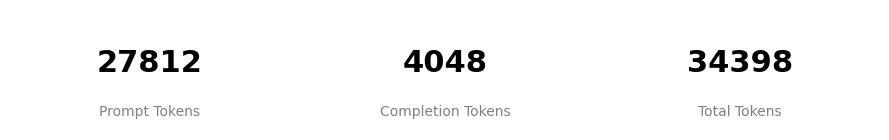

In [12]:
# Cell 9: Token KPI cards
df = run("""
SELECT
  COALESCE(SUM(prompt_tokens), 0) AS prompt,
  COALESCE(SUM(completion_tokens), 0) AS completion,
  COALESCE(SUM(total_tokens), 0) AS total
FROM llm_events
WHERE event_type = 'LLM_RESPONSE'
""")
kpi_row(
    ["Prompt Tokens", "Completion Tokens", "Total Tokens"],
    [df["prompt"][0], df["completion"][0], df["total"][0]],
)

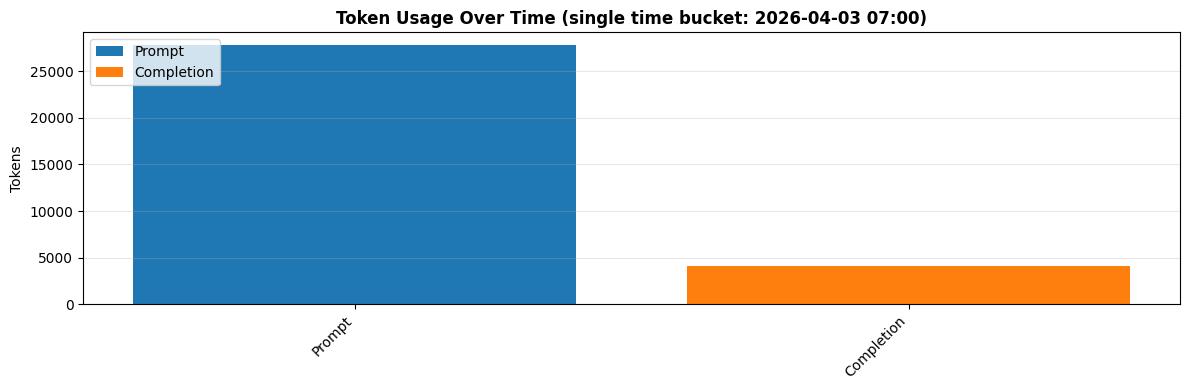

In [13]:
# Cell 10: Token usage over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  COALESCE(SUM(prompt_tokens), 0) AS prompt,
  COALESCE(SUM(completion_tokens), 0) AS completion
FROM llm_events
WHERE event_type = 'LLM_RESPONSE'
GROUP BY hour ORDER BY hour
""")
time_plot(df, "hour", ["prompt", "completion"],
          "Token Usage Over Time", "Tokens", kind="area",
          labels=["Prompt", "Completion"])

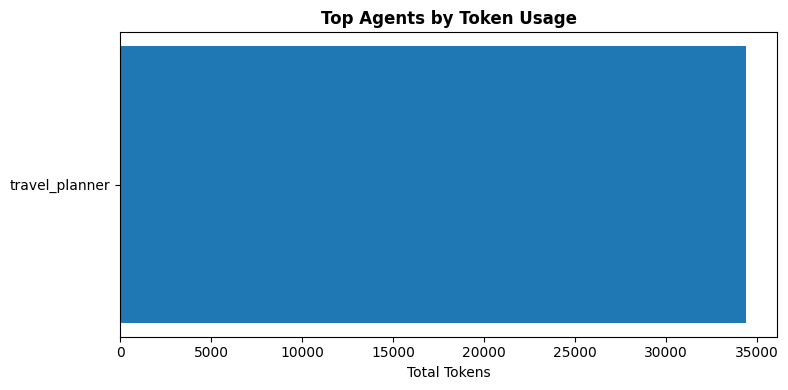

In [14]:
# Cell 11: Top agents by token usage
df = run("""
SELECT agent, COALESCE(SUM(total_tokens), 0) AS total
FROM llm_events WHERE event_type = 'LLM_RESPONSE'
GROUP BY agent ORDER BY total DESC LIMIT 10
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(df["agent"].fillna("(unknown)"), df["total"])
    ax.set_title("Top Agents by Token Usage", fontweight="bold")
    ax.set_xlabel("Total Tokens")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No agent token data.")

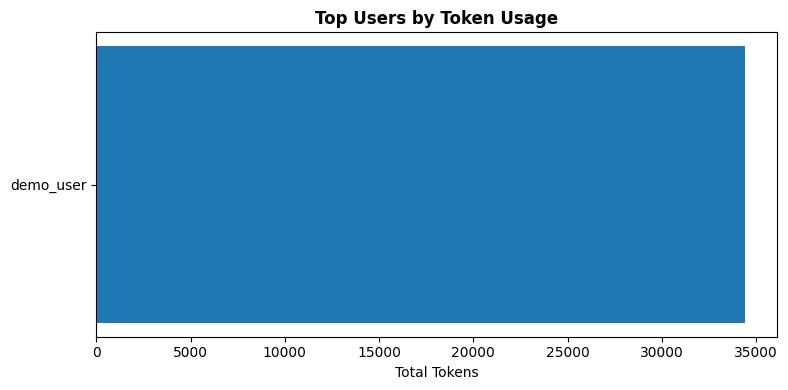

In [15]:
# Cell 12: Top users by token usage
df = run("""
SELECT user_id, COALESCE(SUM(total_tokens), 0) AS total
FROM llm_events WHERE event_type = 'LLM_RESPONSE'
GROUP BY user_id ORDER BY total DESC LIMIT 10
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(df["user_id"].fillna("(unknown)"), df["total"])
    ax.set_title("Top Users by Token Usage", fontweight="bold")
    ax.set_xlabel("Total Tokens")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No user token data.")

## Panel 2: Usage Volume

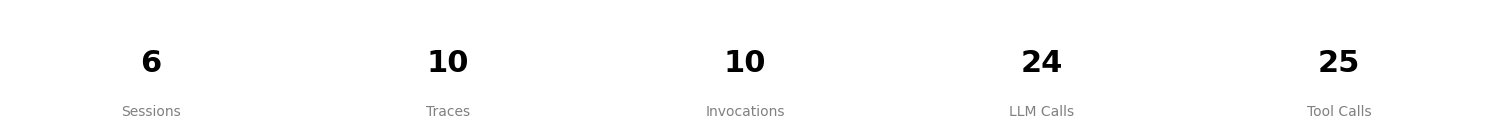

In [16]:
# Cell 13: Usage volume KPI cards
df = run("""
SELECT
  COUNT(*) AS sessions,
  COALESCE(SUM(trace_count), 0) AS traces,
  COALESCE(SUM(invocation_count), 0) AS invocations,
  COALESCE(SUM(llm_calls), 0) AS llm,
  COALESCE(SUM(tool_calls), 0) AS tools
FROM session_rollups
""")
kpi_row(
    ["Sessions", "Traces", "Invocations", "LLM Calls", "Tool Calls"],
    [df["sessions"][0], df["traces"][0], df["invocations"][0],
     df["llm"][0], df["tools"][0]],
)

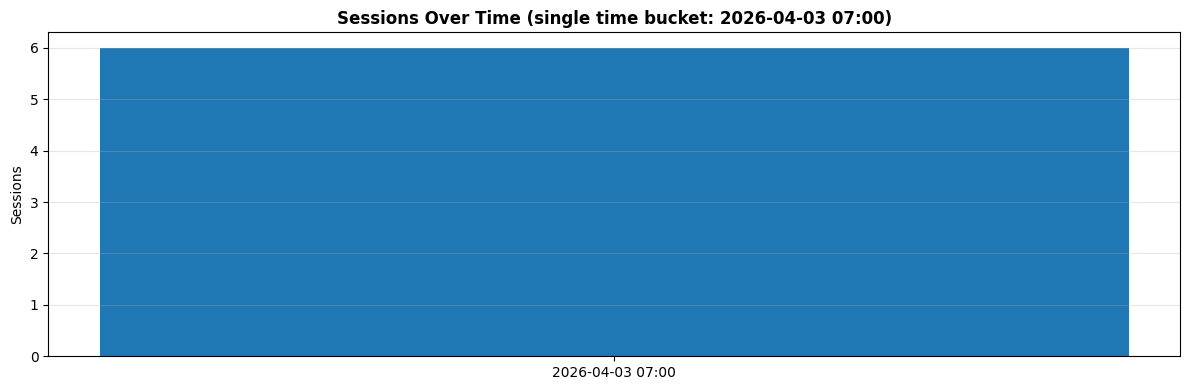

In [17]:
# Cell 14: Sessions over time
df = run("""
SELECT TIMESTAMP_TRUNC(start_ts, HOUR) AS hour, COUNT(*) AS sessions
FROM session_rollups GROUP BY hour ORDER BY hour
""")
time_plot(df, "hour", "sessions", "Sessions Over Time", "Sessions")

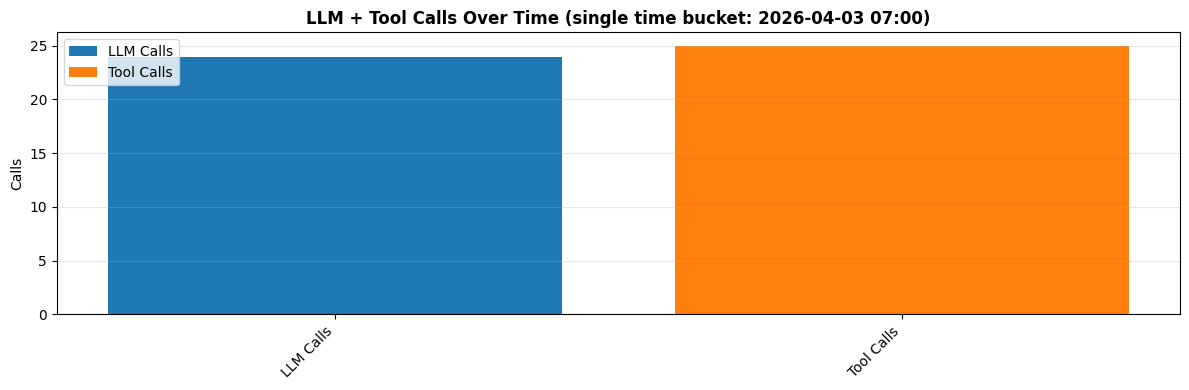

In [18]:
# Cell 15: LLM + Tool calls over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  COUNTIF(event_type = 'LLM_REQUEST') AS llm_calls,
  COUNTIF(event_type = 'TOOL_STARTING') AS tool_calls
FROM filtered_events
GROUP BY hour ORDER BY hour
""")
time_plot(df, "hour", ["llm_calls", "tool_calls"],
          "LLM + Tool Calls Over Time", "Calls", kind="area",
          labels=["LLM Calls", "Tool Calls"])

## Panel 3: Reliability

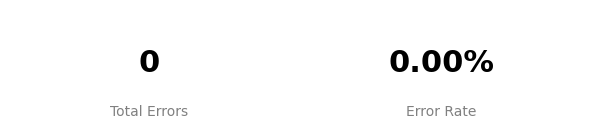

In [19]:
# Cell 16: Error KPI cards
df = run("""
SELECT
  COUNTIF(is_error) AS total_errors,
  SAFE_DIVIDE(COUNTIF(is_error), COUNT(*)) AS error_rate
FROM filtered_events
""")
rate_pct = f"{df['error_rate'][0] * 100:.2f}%" if df['error_rate'][0] else "0.00%"
kpi_row(["Total Errors", "Error Rate"], [df["total_errors"][0], rate_pct])

In [20]:
# Cell 17: Errors over time by event family
df = run("""
SELECT TIMESTAMP_TRUNC(timestamp, HOUR) AS hour, event_family, COUNT(*) AS errors
FROM filtered_events WHERE is_error
GROUP BY hour, event_family ORDER BY hour
""")
if not df.empty:
    if len(df["hour"].unique()) == 1:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(df["event_family"], df["errors"])
        ax.set_title(f"Errors by Event Family (at {str(df['hour'].iloc[0])[:16]})", fontweight="bold")
        ax.set_ylabel("Errors")
        plt.tight_layout()
        plt.show()
    else:
        pivot = df.pivot_table(index="hour", columns="event_family", values="errors", fill_value=0)
        fig, ax = plt.subplots(figsize=(12, 4))
        pivot.plot.area(ax=ax, alpha=0.7, stacked=True)
        fmt_ax(ax, "Errors Over Time by Event Family", ylabel="Errors")
        ax.legend(loc="upper left", fontsize=8)
        plt.tight_layout()
        plt.show()
else:
    print("No errors found.")

No errors found.


In [21]:
# Cell 18: Tool errors by tool name + origin
df = run("""
SELECT
  COALESCE(tool_name, '(unknown)') AS tool,
  COALESCE(tool_origin, '(default)') AS origin,
  COUNT(*) AS errors
FROM tool_events WHERE is_error
GROUP BY tool, origin ORDER BY errors DESC LIMIT 15
""")
if not df.empty:
    labels = df["tool"] + " / " + df["origin"]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(labels, df["errors"])
    ax.set_title("Tool Errors by Name + Origin", fontweight="bold")
    ax.set_xlabel("Errors")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No tool errors.")

No tool errors.


In [22]:
# Cell 19: LLM errors by model
df = run("""
SELECT COALESCE(model, '(unknown)') AS model, COUNT(*) AS errors
FROM llm_events WHERE is_error
GROUP BY model ORDER BY errors DESC LIMIT 10
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(df["model"], df["errors"])
    ax.set_title("LLM Errors by Model", fontweight="bold")
    ax.set_xlabel("Errors")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No LLM errors.")

No LLM errors.


## Panel 4: Performance — Latency

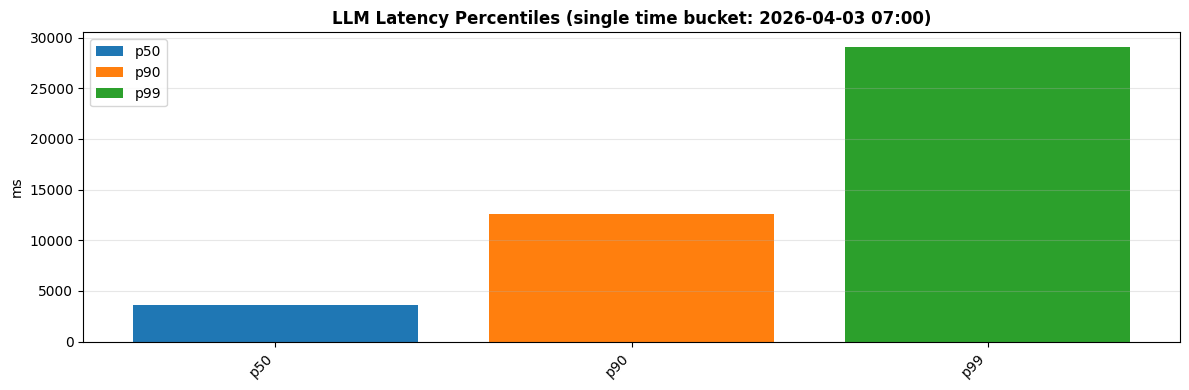

In [23]:
# Cell 20: LLM latency p50/p90/p99 over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(50)] AS p50,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(90)] AS p90,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(99)] AS p99
FROM llm_events
WHERE event_type = 'LLM_RESPONSE' AND total_ms IS NOT NULL
GROUP BY hour ORDER BY hour
""")
time_plot(df, "hour", ["p50", "p90", "p99"],
          "LLM Latency Percentiles", "ms",
          labels=["p50", "p90", "p99"])

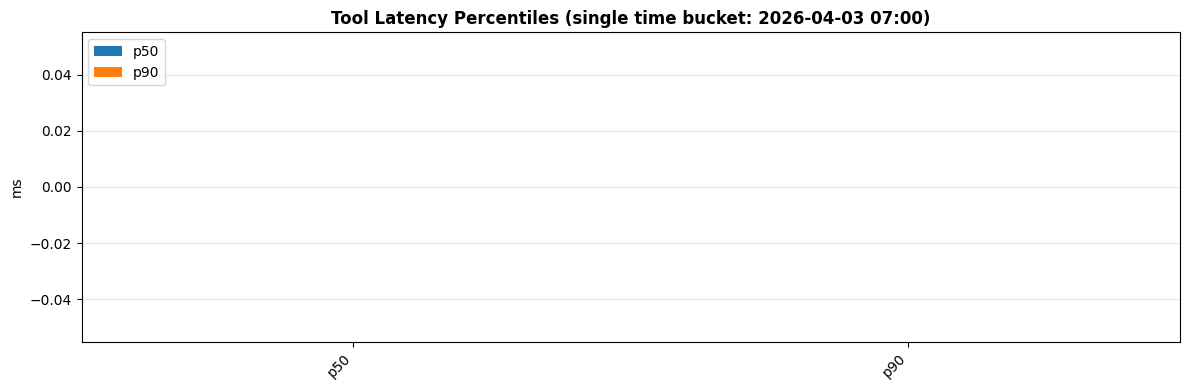

In [24]:
# Cell 21: Tool latency p50/p90 over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(50)] AS p50,
  APPROX_QUANTILES(total_ms, 100)[OFFSET(90)] AS p90
FROM tool_events
WHERE event_type = 'TOOL_COMPLETED' AND total_ms IS NOT NULL
GROUP BY hour ORDER BY hour
""")
time_plot(df, "hour", ["p50", "p90"],
          "Tool Latency Percentiles", "ms",
          labels=["p50", "p90"])

## Panel 5: Performance — TTFT (Time To First Token)

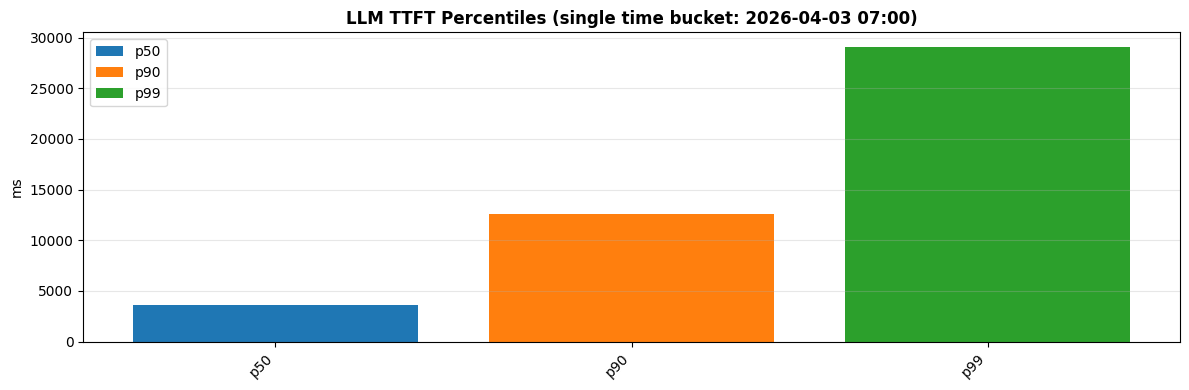

In [25]:
# Cell 22: TTFT p50/p90/p99 over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
  APPROX_QUANTILES(ttft_ms, 100)[OFFSET(50)] AS p50,
  APPROX_QUANTILES(ttft_ms, 100)[OFFSET(90)] AS p90,
  APPROX_QUANTILES(ttft_ms, 100)[OFFSET(99)] AS p99
FROM llm_events
WHERE event_type = 'LLM_RESPONSE' AND ttft_ms IS NOT NULL
GROUP BY hour ORDER BY hour
""")
time_plot(df, "hour", ["p50", "p90", "p99"],
          "LLM TTFT Percentiles", "ms",
          labels=["p50", "p90", "p99"])

## Panel 6: Session Duration

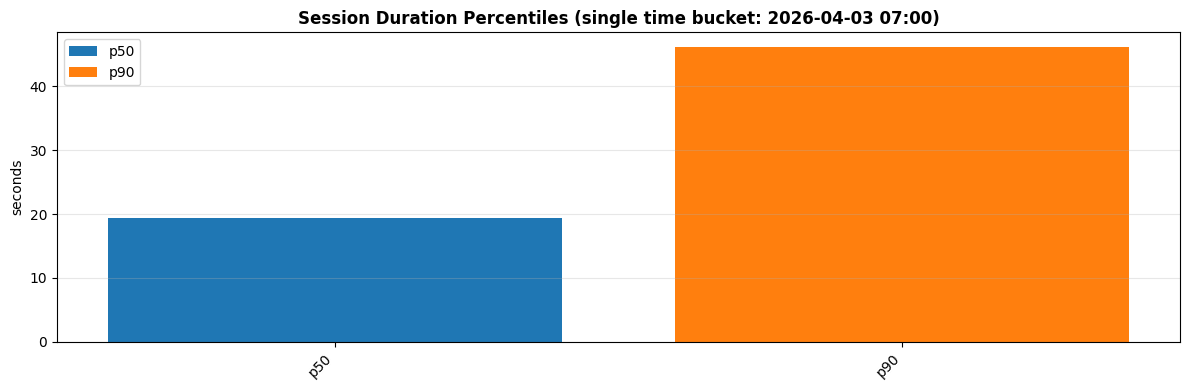

In [26]:
# Cell 23: Session duration p50/p90 over time
df = run("""
SELECT
  TIMESTAMP_TRUNC(start_ts, HOUR) AS hour,
  APPROX_QUANTILES(duration_ms, 100)[OFFSET(50)] / 1000 AS p50_sec,
  APPROX_QUANTILES(duration_ms, 100)[OFFSET(90)] / 1000 AS p90_sec
FROM session_rollups
WHERE duration_ms > 0
GROUP BY hour ORDER BY hour
""")
time_plot(df, "hour", ["p50_sec", "p90_sec"],
          "Session Duration Percentiles", "seconds",
          labels=["p50", "p90"])

## Panel 7: Users

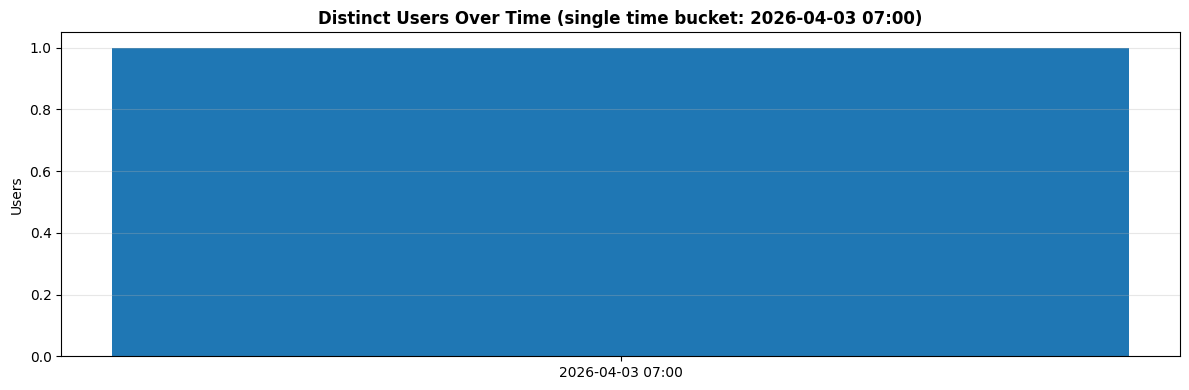

In [27]:
# Cell 24: Distinct users over time
df = run("""
SELECT TIMESTAMP_TRUNC(start_ts, HOUR) AS hour,
       COUNT(DISTINCT user_id) AS users
FROM session_rollups
GROUP BY hour ORDER BY hour
""")
time_plot(df, "hour", "users", "Distinct Users Over Time", "Users")

In [28]:
# Cell 25: Top users by sessions
df = run("""
SELECT COALESCE(user_id, '(unknown)') AS user_id, COUNT(*) AS sessions
FROM session_rollups GROUP BY user_id ORDER BY sessions DESC LIMIT 10
""")
if not df.empty:
    print("Top Users by Session Count:")
    print(df.to_string(index=False))
else:
    print("No user session data.")

Top Users by Session Count:
  user_id  sessions
demo_user         6


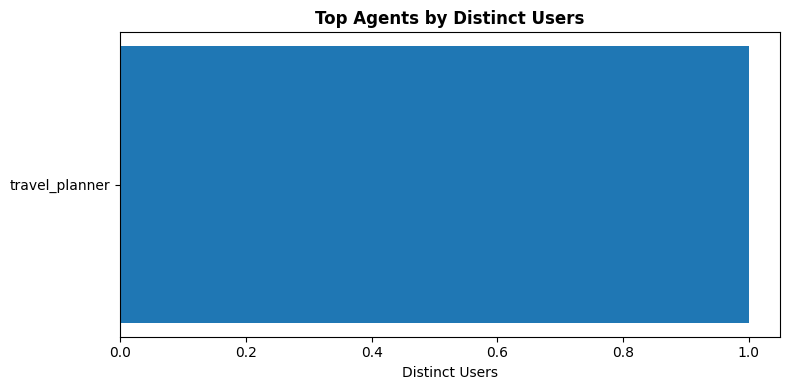

In [29]:
# Cell 26: Top agents by distinct users
df = run("""
SELECT COALESCE(agent, '(unknown)') AS agent, COUNT(DISTINCT user_id) AS users
FROM session_rollups GROUP BY agent ORDER BY users DESC LIMIT 10
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(df["agent"], df["users"])
    ax.set_title("Top Agents by Distinct Users", fontweight="bold")
    ax.set_xlabel("Distinct Users")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No agent user data.")

## Panel 8: HITL / Orchestration

In [30]:
# Cell 27: HITL requests over time by type
df = run("""
SELECT TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
       hitl_type, COUNT(*) AS requests
FROM hitl_events WHERE NOT is_completed
GROUP BY hour, hitl_type ORDER BY hour
""")
if not df.empty:
    if len(df["hour"].unique()) == 1:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(df["hitl_type"].fillna("(unknown)"), df["requests"])
        ax.set_title(f"HITL Requests by Type (at {str(df['hour'].iloc[0])[:16]})", fontweight="bold")
        ax.set_ylabel("Requests")
        plt.tight_layout()
        plt.show()
    else:
        pivot = df.pivot_table(index="hour", columns="hitl_type", values="requests", fill_value=0)
        fig, ax = plt.subplots(figsize=(12, 4))
        pivot.plot.area(ax=ax, alpha=0.7, stacked=True)
        fmt_ax(ax, "HITL Requests Over Time by Type", ylabel="Requests")
        ax.legend(loc="upper left")
        plt.tight_layout()
        plt.show()
else:
    print("No HITL request events found.")

No HITL request events found.


In [31]:
# Cell 28: HITL completion rate by type
df = run("""
SELECT hitl_type,
       COUNTIF(NOT is_completed) AS requests,
       COUNTIF(is_completed) AS completions
FROM hitl_events
GROUP BY hitl_type
""")
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(len(df))
    w = 0.35
    ax.bar([i - w/2 for i in x], df["requests"], w, label="Requests")
    ax.bar([i + w/2 for i in x], df["completions"], w, label="Completions")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["hitl_type"].fillna("(unknown)"))
    ax.set_title("HITL Completion Rate by Type", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No HITL events found.")

No HITL events found.


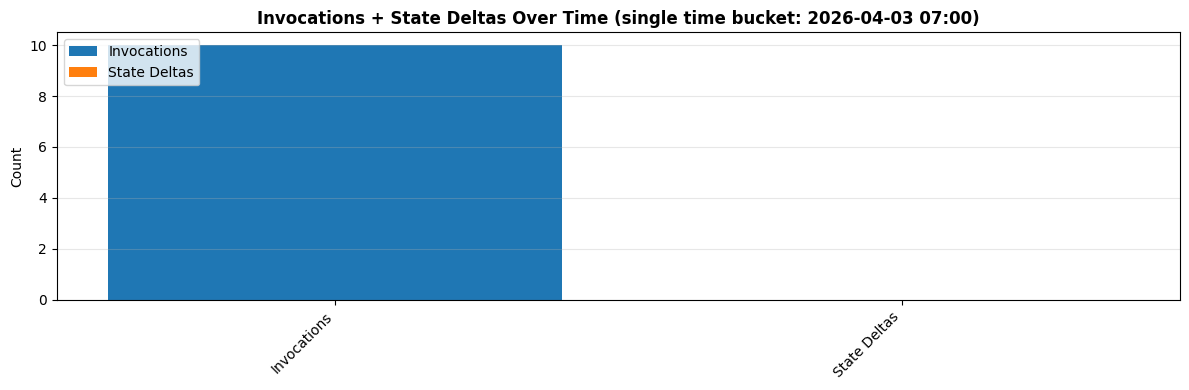

In [32]:
# Cell 29: Invocations + state deltas over time
df = run("""
SELECT TIMESTAMP_TRUNC(start_ts, HOUR) AS hour,
       SUM(invocation_count) AS invocations,
       SUM(state_deltas) AS state_deltas
FROM session_rollups
GROUP BY hour ORDER BY hour
""")
time_plot(df, "hour", ["invocations", "state_deltas"],
          "Invocations + State Deltas Over Time", "Count",
          labels=["Invocations", "State Deltas"])

## Panel 9: Multimodal

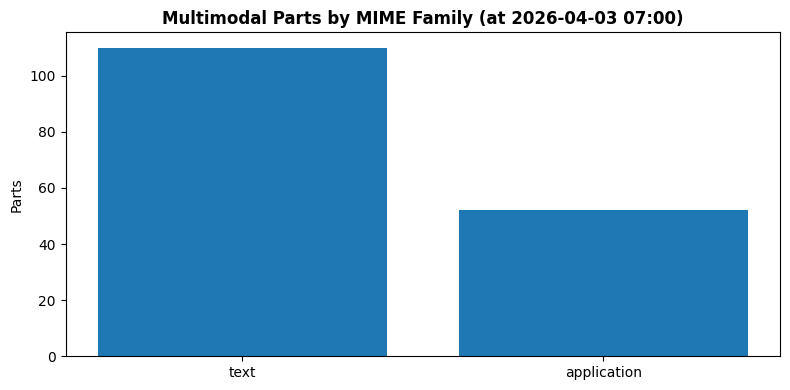

In [33]:
# Cell 30: Content by mime_family over time
df = run("""
SELECT TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
       COALESCE(mime_family, '(unknown)') AS mime_family,
       COUNT(*) AS parts
FROM multimodal_parts
GROUP BY hour, mime_family ORDER BY hour
""")
if not df.empty:
    if len(df["hour"].unique()) == 1:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(df["mime_family"], df["parts"])
        ax.set_title(f"Multimodal Parts by MIME Family (at {str(df['hour'].iloc[0])[:16]})", fontweight="bold")
        ax.set_ylabel("Parts")
        plt.tight_layout()
        plt.show()
    else:
        pivot = df.pivot_table(index="hour", columns="mime_family", values="parts", fill_value=0)
        fig, ax = plt.subplots(figsize=(12, 4))
        pivot.plot.area(ax=ax, alpha=0.7, stacked=True)
        fmt_ax(ax, "Multimodal Content by MIME Family Over Time", ylabel="Parts")
        ax.legend(loc="upper left")
        plt.tight_layout()
        plt.show()
else:
    print("No multimodal content found.")

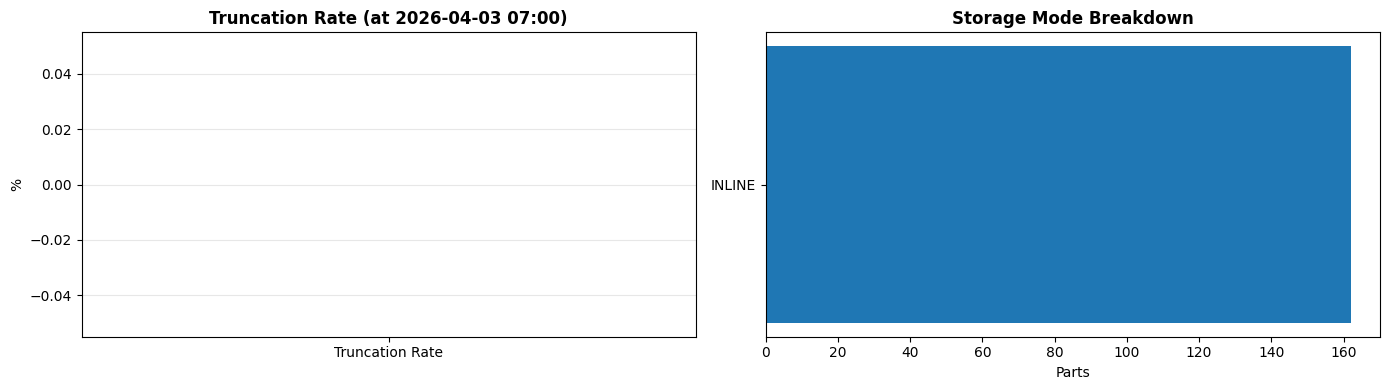

In [34]:
# Cell 31: Truncation rate + storage mode breakdown
df_trunc = run("""
SELECT TIMESTAMP_TRUNC(timestamp, HOUR) AS hour,
       SAFE_DIVIDE(COUNTIF(is_truncated), COUNT(*)) AS truncation_rate
FROM multimodal_parts
GROUP BY hour ORDER BY hour
""")
df_storage = run("""
SELECT COALESCE(storage_mode, '(unset)') AS storage_mode, COUNT(*) AS parts
FROM multimodal_parts
GROUP BY storage_mode ORDER BY parts DESC
""")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
if not df_trunc.empty:
    if len(df_trunc) == 1:
        rate = df_trunc["truncation_rate"].iloc[0] or 0
        ax1.bar(["Truncation Rate"], [rate * 100], color="red", alpha=0.7)
        ax1.set_title(f"Truncation Rate (at {str(df_trunc['hour'].iloc[0])[:16]})", fontweight="bold")
    else:
        ax1.plot(df_trunc["hour"], df_trunc["truncation_rate"] * 100, linewidth=2, color="red")
        ax1.set_title("Truncation Rate Over Time", fontweight="bold")
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax1.set_ylabel("%")
    ax1.grid(axis="y", alpha=0.3)
else:
    ax1.text(0.5, 0.5, "No truncation data", ha="center", va="center", transform=ax1.transAxes)
    ax1.set_title("Truncation Rate", fontweight="bold")
if not df_storage.empty:
    ax2.barh(df_storage["storage_mode"], df_storage["parts"])
    ax2.set_title("Storage Mode Breakdown", fontweight="bold")
    ax2.set_xlabel("Parts")
    ax2.invert_yaxis()
else:
    ax2.text(0.5, 0.5, "No storage mode data", ha="center", va="center", transform=ax2.transAxes)
    ax2.set_title("Storage Mode", fontweight="bold")
plt.tight_layout()
plt.show()

---
# Section 10: Trace Drill-Down

**Separate section, different success criterion.**

The aggregate dashboard answers "how is the system doing?"
The drill-down answers "what happened in this specific trace?"

Set `SESSION_ID_FILTER` or `TRACE_ID_FILTER` above and re-run Layer 1 to scope the drill-down.

In [35]:
# Cell 32: Session list
df = run("""
SELECT
  session_id,
  agent,
  start_ts,
  end_ts,
  duration_ms,
  total_events,
  has_error,
  has_multimodal,
  trace_count
FROM session_rollups
ORDER BY start_ts DESC
LIMIT 30
""")
print(f"Recent sessions ({len(df)} shown):")
print(df.to_string(index=False))

Recent sessions (6 shown):
      session_id          agent                         start_ts                           end_ts  duration_ms  total_events  has_error  has_multimodal  trace_count
e2e-a9b40dfdbe84 travel_planner 2026-04-03 07:44:09.959171+00:00 2026-04-03 07:44:56.141283+00:00        46182            33      False            True            3
e2e-054c12957ba3 travel_planner 2026-04-03 07:43:59.632517+00:00 2026-04-03 07:44:09.553076+00:00         9920            19      False            True            1
e2e-781fb52f3814 travel_planner 2026-04-03 07:43:46.386415+00:00 2026-04-03 07:43:59.242929+00:00        12856            21      False            True            1
e2e-3171eb36991f travel_planner 2026-04-03 07:37:14.206646+00:00 2026-04-03 07:37:40.342719+00:00        26136            33      False            True            3
e2e-f676e06a719e travel_planner 2026-04-03 07:36:54.241866+00:00 2026-04-03 07:37:13.697492+00:00        19455            19      False            T

In [36]:
# Cell 33: Span tree for a session
# Pick the most recent session (or set SESSION_ID_FILTER above)
target_session = df["session_id"].iloc[0] if not df.empty else None

if target_session:
    # Query all events for the session
    events = run(f"""
    SELECT
      span_id,
      parent_span_id,
      event_type,
      event_family,
      agent,
      status,
      error_message,
      CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms,
      CAST(JSON_VALUE(latency_ms, '$.time_to_first_token_ms') AS FLOAT64) AS ttft_ms,
      timestamp
    FROM filtered_events
    WHERE session_id = '{target_session}'
    ORDER BY timestamp
    """)

    # Aggregate events into spans (deduplicate by span_id)
    span_map = {}
    for _, row in events.iterrows():
        sid = row.get("span_id")
        if not sid:
            continue
        if sid not in span_map:
            span_map[sid] = {
                "span_id": sid,
                "parent_span_id": row.get("parent_span_id"),
                "agent": row.get("agent"),
                "events": [],
                "total_ms": None,
                "ttft_ms": None,
                "has_error": False,
                "error_message": None,
            }
        span_map[sid]["events"].append(row.get("event_type", ""))
        # Capture latency from whichever event has it
        if row.get("total_ms") and row["total_ms"] > 0:
            span_map[sid]["total_ms"] = row["total_ms"]
        if row.get("ttft_ms") and row["ttft_ms"] > 0:
            span_map[sid]["ttft_ms"] = row["ttft_ms"]
        if row.get("error_message"):
            span_map[sid]["has_error"] = True
            span_map[sid]["error_message"] = row["error_message"]
        if row.get("status") == "ERROR":
            span_map[sid]["has_error"] = True

    # Build tree from parent_span_id
    children = {}
    roots = []
    for sid, span in span_map.items():
        pid = span.get("parent_span_id")
        if pid and pid in span_map:
            children.setdefault(pid, []).append(span)
        else:
            roots.append(span)

    def print_tree(node, indent=0):
        sid = node["span_id"][:8]
        evts = ", ".join(node["events"])
        ag = node.get("agent") or ""
        lat = node.get("total_ms")
        err = node.get("error_message")
        prefix = "  " * indent
        err_mark = " *** ERROR" if node["has_error"] else ""
        lat_str = f" ({lat:.0f}ms)" if lat and lat > 0 else ""
        print(f"{prefix}[{sid}] events=[{evts}] agent={ag}{lat_str}{err_mark}")
        if err:
            print(f"{prefix}  error: {str(err)[:100]}")
        for child in children.get(node["span_id"], []):
            print_tree(child, indent + 1)

    print(f"Span tree for session: {target_session}")
    print(f"Total events: {len(events)}, Unique spans: {len(span_map)}")
    print("=" * 70)
    for root in roots:
        print_tree(root)
else:
    print("No sessions available for drill-down.")


Span tree for session: e2e-a9b40dfdbe84
Total events: 33, Unique spans: 15
[1c5d2a3d] events=[USER_MESSAGE_RECEIVED, INVOCATION_STARTING, INVOCATION_COMPLETED] agent=travel_planner (4078ms)
  [4da56afc] events=[AGENT_STARTING, AGENT_COMPLETED] agent=travel_planner (4077ms)
    [ca1069a7] events=[LLM_REQUEST, LLM_RESPONSE] agent=travel_planner (2148ms)
    [0c421077] events=[TOOL_STARTING, TOOL_COMPLETED] agent=travel_planner
    [cb1f5828] events=[LLM_REQUEST, LLM_RESPONSE] agent=travel_planner (1914ms)
[6d944fa2] events=[USER_MESSAGE_RECEIVED, INVOCATION_STARTING, INVOCATION_COMPLETED] agent=travel_planner (35705ms)
  [c11e0281] events=[AGENT_STARTING, AGENT_COMPLETED] agent=travel_planner (35704ms)
    [6a6e6b52] events=[LLM_REQUEST, LLM_RESPONSE] agent=travel_planner (29060ms)
    [ba01fa7e] events=[TOOL_STARTING, TOOL_COMPLETED] agent=travel_planner
    [8a1d7785] events=[LLM_REQUEST, LLM_RESPONSE] agent=travel_planner (6631ms)
[edaac2cc] events=[USER_MESSAGE_RECEIVED, INVOCATION_S

In [37]:
# Cell 34: Span detail — pick a span to inspect
if target_session:
    detail = run(f"""
    SELECT
      span_id, parent_span_id, event_type, agent, status,
      error_message, is_truncated,
      JSON_VALUE(latency_ms, '$.total_ms') AS total_ms,
      JSON_VALUE(latency_ms, '$.time_to_first_token_ms') AS ttft_ms,
      SUBSTR(TO_JSON_STRING(content), 0, 500) AS content_preview,
      SUBSTR(TO_JSON_STRING(attributes), 0, 500) AS attributes_preview,
      ARRAY_LENGTH(content_parts) AS content_parts_count,
      timestamp
    FROM filtered_events
    WHERE session_id = '{target_session}'
    ORDER BY timestamp
    LIMIT 20
    """)
    for _, row in detail.iterrows():
        print(f"--- {row['event_type']} (span: {str(row.get('span_id',''))[:8]}) ---")
        print(f"  agent: {row.get('agent')}  status: {row.get('status')}")
        if row.get("total_ms"):
            print(f"  latency: {row['total_ms']}ms", end="")
            if row.get("ttft_ms"):
                print(f"  ttft: {row['ttft_ms']}ms", end="")
            print()
        if row.get("error_message"):
            print(f"  error: {str(row['error_message'])[:200]}")
        if row.get("content_parts_count") and int(row["content_parts_count"]) > 0:
            print(f"  multimodal: {row['content_parts_count']} part(s)")
        if row.get("content_preview"):
            print(f"  content: {str(row['content_preview'])[:200]}...")
        print()
else:
    print("No session selected.")

--- USER_MESSAGE_RECEIVED (span: 1c5d2a3d) ---
  agent: travel_planner  status: OK
  multimodal: 1 part(s)
  content: {"text_summary":"What's the weather like in Paris on 2025-04-20?"}...

--- INVOCATION_STARTING (span: 1c5d2a3d) ---
  agent: travel_planner  status: OK
  content: null...

--- AGENT_STARTING (span: 4da56afc) ---
  agent: travel_planner  status: OK
  content: "You are a helpful travel planning assistant. You help users plan trips by\nsearching for flights, hotels, checking weather forecasts, and calculating\nbudgets.\n\nGuidelines:\n- Always search for fli...

--- LLM_REQUEST (span: ca1069a7) ---
  agent: travel_planner  status: OK
  multimodal: 1 part(s)
  content: {"prompt":[{"content":"What's the weather like in Paris on 2025-04-20?","role":"user"}],"system_prompt":"You are a helpful travel planning assistant. You help users plan trips by\nsearching for flight...

--- LLM_RESPONSE (span: ca1069a7) ---
  agent: travel_planner  status: OK
  latency: 2148ms  ttft: 2148ms

In [38]:
# Cell 35: Error chain — trace error propagation
if target_session:
    errors = run(f"""
    SELECT span_id, parent_span_id, event_type, agent, error_message,
           CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms,
           timestamp
    FROM filtered_events
    WHERE session_id = '{target_session}'
      AND (ENDS_WITH(event_type, '_ERROR')
           OR error_message IS NOT NULL
           OR status = 'ERROR')
    ORDER BY timestamp
    """)
    if not errors.empty:
        # Build span lookup for the full session
        all_spans = run(f"""
        SELECT span_id, parent_span_id, event_type, agent
        FROM filtered_events
        WHERE session_id = '{target_session}'
        """)
        span_map = {r["span_id"]: r for _, r in all_spans.iterrows() if r.get("span_id")}

        print(f"Error chain for session: {target_session}")
        print(f"Found {len(errors)} error event(s):")
        print("=" * 70)
        for _, err in errors.iterrows():
            print(f"\nError: {err['event_type']} (agent={err.get('agent')})")
            print(f"  message: {str(err.get('error_message',''))[:200]}")
            # Walk up to root
            chain = []
            current = err.get("span_id")
            visited = set()
            while current and current in span_map and current not in visited:
                visited.add(current)
                s = span_map[current]
                chain.append(f"{s.get('event_type','')} [agent={s.get('agent','')}]")
                current = s.get("parent_span_id")
            if chain:
                print("  propagation path (leaf → root):")
                for i, step in enumerate(chain):
                    print(f"    {'  ' * i}→ {step}")
    else:
        print("No errors in this session.")
else:
    print("No session selected.")

No errors in this session.


---

In [39]:
print("Dashboard V2 complete.")
print(f"  Layers: 7 base tables (Layer 1) + 23 charts + 4 drill-down views (Layer 2)")
print(f"  Data source: {TABLE_REF}")
print(f"  Time range: last {TIME_RANGE_HOURS} hours")

# Clean up BigQuery session
try:
    client.query(f"CALL BQ.ABORT_SESSION('{SESSION_ID}')", job_config=_job_config()).result()
    print(f"  Session {SESSION_ID[:16]}... closed.")
except Exception:
    print(f"  Session will auto-expire.")

Dashboard V2 complete.
  Layers: 7 base tables (Layer 1) + 23 charts + 4 drill-down views (Layer 2)
  Data source: `test-project-0728-467323.agent_analytics.agent_events`
  Time range: last 720 hours


  Session ChoKGHRlc3QtcHJv... closed.
